# What Makes a Country Happy? — A Data-Driven Analysis
### Using the World Happiness Report 2015-2019

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/merged.csv")

df.head()

,country,happiness_rank,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,corruption,generosity,year
0,Switzerland,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
3,Norway,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
4,Canada,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015


## Introduction


Understanding how to achieve a happy population is extremely important. A happy population ensures maximum productivity and fulfils the goal of a national level organisation who want to work for the betterment of their people. This data is also important at the national level as it helps international organisations identify which countries need help and intervention.

The current problem many individual countries have in improving their happiness is not understanding what actually affects the happiness scores of their own people. This lack of understanding can cause problems in productivity and development.

My study and ARIA, a rule based system bridge this lack of understanding. This research report goes over what are the important factors to invest in to make the overall  population happy. ARIA can find weakness and strengths of a country and evaluate which factors the country can improve in.

Finding some relevant statistics of happiness score and gdp per capita. 

In [2]:
df["gdp_per_capita"].describe()

count    782.000000
mean       0.916047
std        0.407340
min        0.000000
25%        0.606500
50%        0.982205
75%        1.236187
max        2.096000
Name: gdp_per_capita, dtype: float64

In [3]:
df["happiness_score"].describe()

count    782.000000
mean       5.379018
std        1.127456
min        2.693000
25%        4.509750
50%        5.322000
75%        6.189500
max        7.769000
Name: happiness_score, dtype: float64

### Section 1 : What drives happiness ?

#### Q Which factors contribute the most to the overall happiness of the population ? 

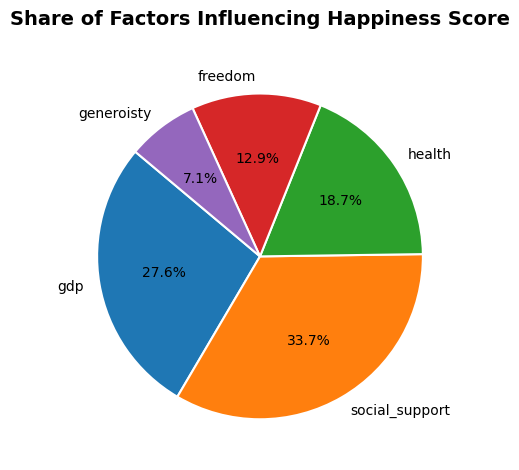

In [ ]:
happiness_score = df["happiness_score"]

factors = {
    "gdp" : df["gdp_per_capita"],
    "social_support" : df["social_support"],
    "health" : df["life_expectancy"],
    "freedom" : df["freedom"],
    "generosity" : df["generosity"],
}

values =[]
keys = []
for key, value in factors.items():
    influence = sum(value / happiness_score)/len(happiness_score)  
    values.append(influence)
    keys.append(key)



plt.pie(
    values,
    labels=keys,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
plt.title("Share of Factors Influencing Happiness Score", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("../outputs/graphs/pie_factors_influencing_happiness_score.png", dpi=150, bbox_inches='tight')
plt.show()


In [5]:
df[["happiness_score","gdp_per_capita","social_support",
        "life_expectancy","freedom","generosity","corruption"]].corr()["happiness_score"]

happiness_score    1.000000
gdp_per_capita     0.789284
social_support     0.648799
life_expectancy    0.742456
freedom            0.551258
generosity         0.137578
corruption         0.398418
Name: happiness_score, dtype: float64

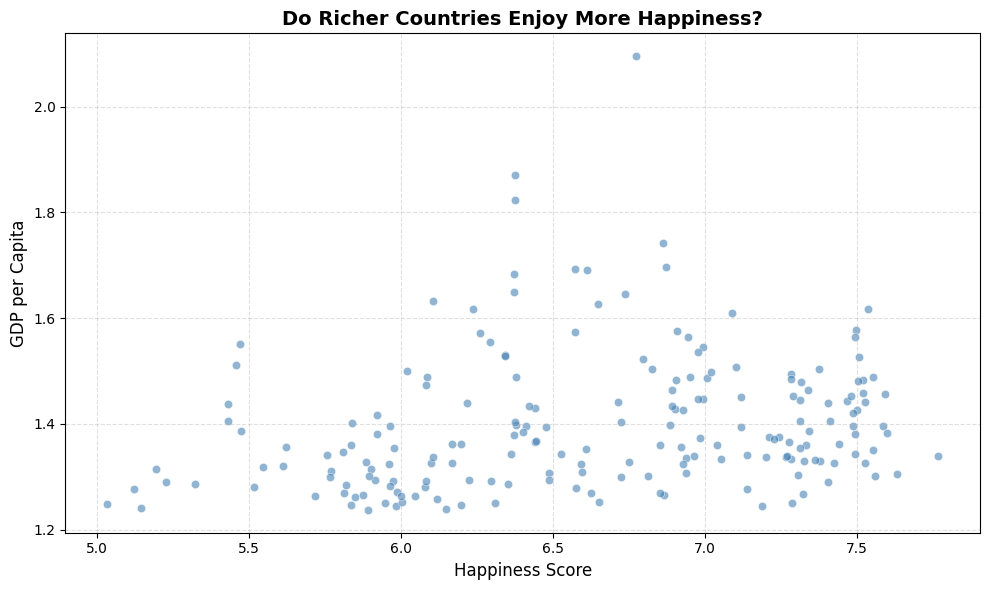

In [6]:
rich = df[df["gdp_per_capita"] > 1.236]

plt.figure(figsize=(10, 6))
plt.scatter(rich["happiness_score"], rich["gdp_per_capita"], 
            color="steelblue", alpha=0.6, edgecolors="white", linewidth=0.5)
plt.xlabel("Happiness Score", fontsize=12)
plt.ylabel("GDP per Capita", fontsize=12)
plt.title("Do Richer Countries Enjoy More Happiness?", fontsize=14, fontweight="bold")
plt.grid(axis="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../outputs/graphs/rich_vs_happiness.png", dpi=150, bbox_inches="tight")
plt.show()

 Two different measurements were found each giving different rankings, between who was the more influencing factor wealth or social relations. When each factor was expressed as a proportion  of the happiness score, social relations contributed the most with 33.7 percent, followed by gdp per capita with 27.6 percent and health with 18.7 per cent. However, after calculating the correlations with each factor to the happiness  gdp per capita correlated with happiness score the most  with 0.789284, followed by health with 0.742456 and social support with 0.648799. 


 The "better" measurement as well the reason will be covered in the next section

### Section 2: Rich vs Poor

#### Do richer countries enjoy more freedom,social_support, better health, more generosity ? 

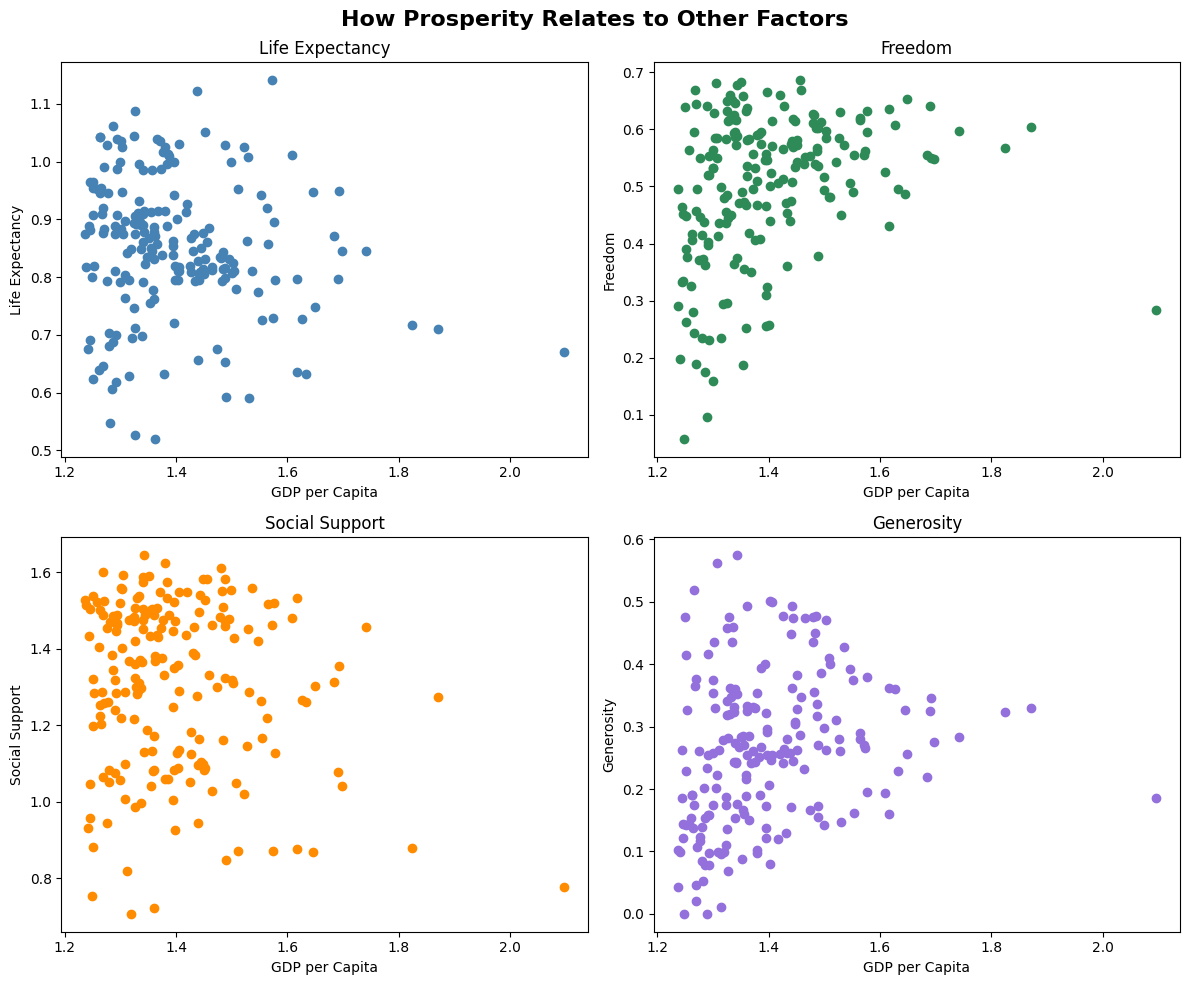

In [7]:
# filter once, reuse
rich = df[df["gdp_per_capita"] > 1.236]

# data
x = rich["gdp_per_capita"]

# subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("How Prosperity Relates to Other Factors", fontsize=16, fontweight="bold")

axes[0, 0].scatter(x, rich["life_expectancy"], color="steelblue")
axes[0, 0].set_title("Life Expectancy")
axes[0, 0].set_xlabel("GDP per Capita")
axes[0, 0].set_ylabel("Life Expectancy")

axes[0, 1].scatter(x, rich["freedom"], color="seagreen")
axes[0, 1].set_title("Freedom")
axes[0, 1].set_xlabel("GDP per Capita")
axes[0, 1].set_ylabel("Freedom")

axes[1, 0].scatter(x, rich["social_support"], color="darkorange")
axes[1, 0].set_title("Social Support")
axes[1, 0].set_xlabel("GDP per Capita")
axes[1, 0].set_ylabel("Social Support")

axes[1, 1].scatter(x, rich["generosity"], color="mediumpurple")
axes[1, 1].set_title("Generosity")
axes[1, 1].set_xlabel("GDP per Capita")
axes[1, 1].set_ylabel("Generosity")

plt.tight_layout()
plt.savefig("../outputs/graphs/rich_enjoy_factors_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

#### Does the poor score as high as the rich in the freedom, health, social relations and generosity ?

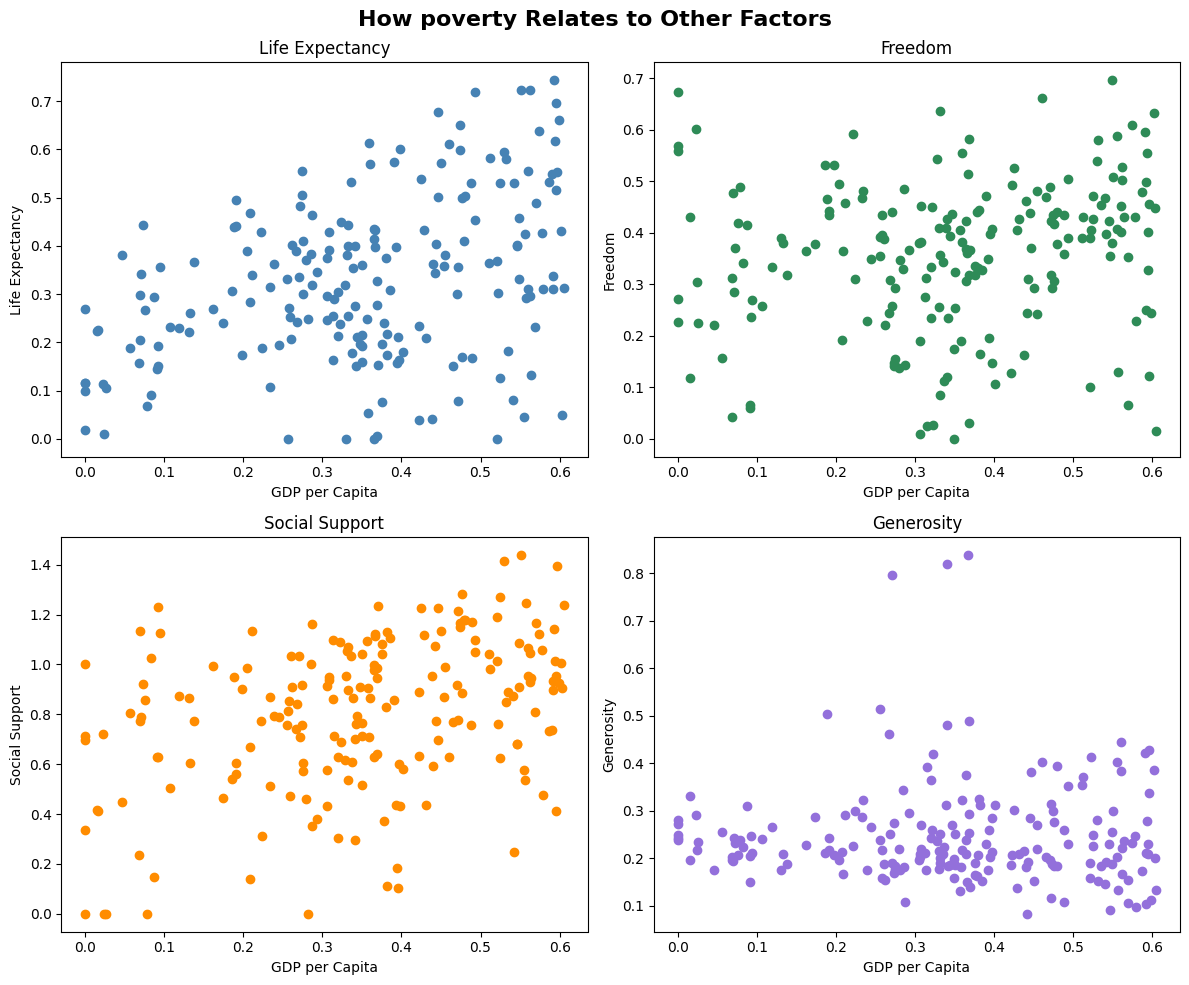

In [8]:
poor = df[df["gdp_per_capita"] < 0.606]

# data
x = poor["gdp_per_capita"]

# subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("How poverty Relates to Other Factors", fontsize=16, fontweight="bold")

axes[0, 0].scatter(x, poor["life_expectancy"], color="steelblue")
axes[0, 0].set_title("Life Expectancy")
axes[0, 0].set_xlabel("GDP per Capita")
axes[0, 0].set_ylabel("Life Expectancy")

axes[0, 1].scatter(x, poor["freedom"], color="seagreen")
axes[0, 1].set_title("Freedom")
axes[0, 1].set_xlabel("GDP per Capita")
axes[0, 1].set_ylabel("Freedom")

axes[1, 0].scatter(x, poor["social_support"], color="darkorange")
axes[1, 0].set_title("Social Support")
axes[1, 0].set_xlabel("GDP per Capita")
axes[1, 0].set_ylabel("Social Support")

axes[1, 1].scatter(x, poor["generosity"], color="mediumpurple")
axes[1, 1].set_title("Generosity")
axes[1, 1].set_xlabel("GDP per Capita")
axes[1, 1].set_ylabel("Generosity")

plt.tight_layout()
plt.savefig("../outputs/graphs/poverty_other_factors_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

#### Are poor countries more prone to corruption than richer countries ? 

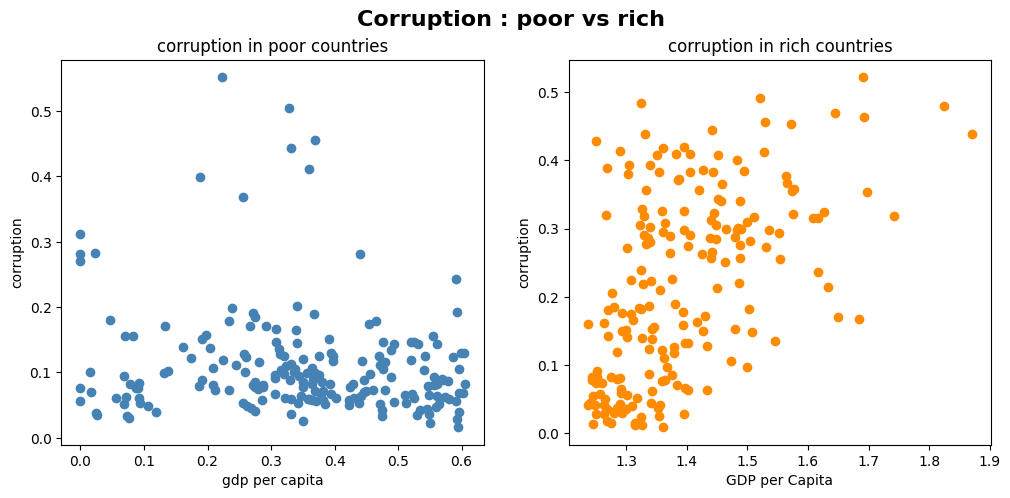

In [ ]:
x1 = poor["gdp_per_capita"]
y1 = poor["corruption"]

x2 = rich["gdp_per_capita"]
y2 = rich["corruption"]


fig,axes = plt.subplots(1,2,figsize=(12,5))
fig.suptitle("Corruption : poor vs rich", fontsize=16, fontweight="bold")

axes[0].scatter(x1,y1, color="steelblue")
axes[0].set_title("corruption in poor countries")
axes[0].set_xlabel("gdp per capita")
axes[0].set_ylabel("corruption")

axes[1].scatter(x2,y2, color="darkorange")
axes[1].set_title("corruption in rich countries")
axes[1].set_xlabel("GDP per Capita")
axes[1].set_ylabel("corruption")
plt.savefig("../outputs/graphs/corruption_difference.png", dpi=150, bbox_inches='tight')

plt.show()




#### Which measurement can be trusted more ? 

After analysing the two different measurements that had formed out of the same data, a conclusion can be achieved that the reason for the high gdp per capita correlation is because it boosts some factors like health,freedom and social relations. This has been verified by plotting a scatter graph showing that the rich scored high in other factors like freedom, health, social relations and generosity , When the same graph was plotted for the poor it showed the opposite, low scores in other factors. One more thing noted is that corruption is more prone in rich countries compared to poor countries. This eliminates corruption from being the reason for the boosted factors.

The correlation measurement is more trusted as it gives more information about the pattern of a happy country, whereas a proportion  contribution does not give us all this information.

#### Can money buy happiness ? 

A key pattern was identified between gdp per capita and happiness score. As explored in this section, The pattern identified was that richer countries scored comparatively higher in factors like freedom,health and social relations than the poor who scored considerably  worse. Corruption was also higher in richer countries but lower in poorer countries. No pattern was seen in generosity, poor or rich had no effect on this factor.

The methodology consisted of plotting scatter graphs of poor and rich and analysing them. The scatter graphs for the rich were plotted for the  countries who were above the 75th percentile of gdp per capita and the scatter graph of the poor were plotted for the countries who were below the 25th percentile of gdp per capita.

Money does not buy happiness but it buys some factors that contribute to a happy population and is still not able to buy factors like generosity and low corruption.

### Section 3 : Outlier detection and global happiness trend

#### Which countries are poor but happy at the same time ? 


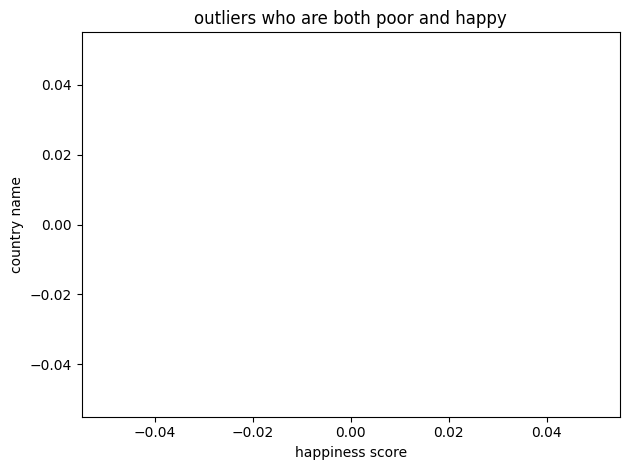

In [10]:
poor_and_happy = df[(df["gdp_per_capita"] < 0.606) & (df["happiness_score"] >  6.189)]

x = poor_and_happy["country"]
y = poor_and_happy["happiness_score"]


plt.barh(x, y)
plt.ylabel("country name")
plt.xlabel("happiness score")
plt.title("outliers who are both poor and happy")
plt.tight_layout()
plt.savefig("../outputs/graphs/poor_and_happy.png", dpi=150, bbox_inches='tight')
plt.show()

When Attempted to find outliers who were below the 25th percentile of poor and above 75th percentile of happiness score, zero outliers were found. This indicates that no country with a low gdp is happy.  This strengthens my argument that gdp per capita is the most important factor to produce a happy population.

#### The global happiness trend

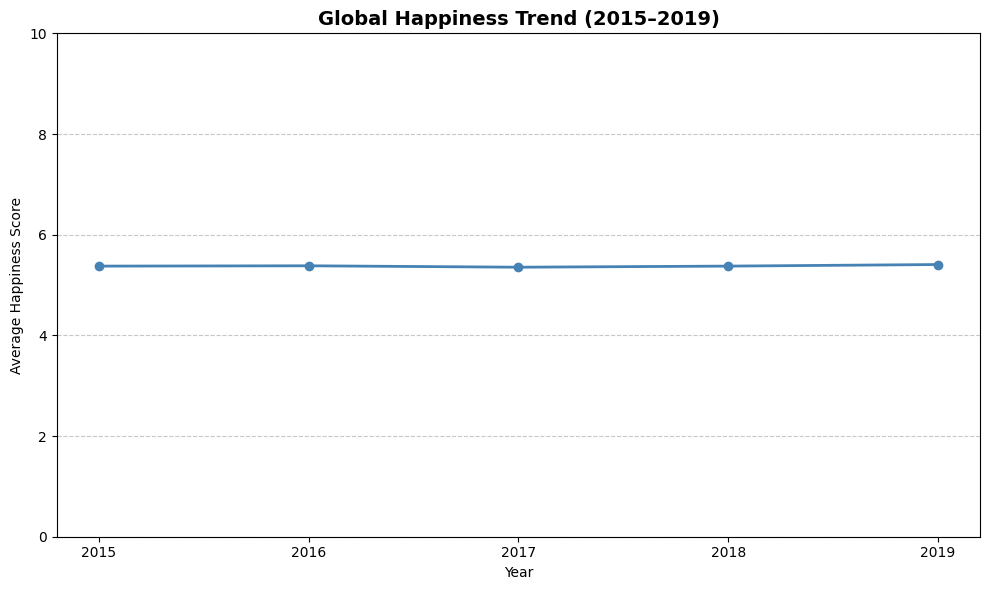

In [11]:
avg_happiness_over_years = []
years = []
for x in range(2015,2020):
    avg_happiness_over_years.append(df[df["year"] ==x]["happiness_score"].mean())
    years.append(x)

y = avg_happiness_over_years 
x = years 

plt.figure(figsize=(10, 6))
plt.plot(x, y, marker='o', linewidth=2, color='steelblue')
plt.xticks([2015, 2016, 2017, 2018, 2019])
plt.ylim(0, 10)
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")
plt.title("Global Happiness Trend (2015–2019)", fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("../outputs/graphs/global_happiness_trend.png", dpi=150, bbox_inches='tight')
plt.show()
     


In [ ]:
# max 
print(max(avg_happiness_over_years)) 
# min 
print(min(avg_happiness_over_years))

5.407096153846155
5.354019355773926


Has the global population grown happier over the years ? It was found that the human population has not grown happier over the years and remained quite stable between 5.35 and 5.40. A minor dip was also noticed in the year 2017, where the happiness score fell by approximately 0.02.

This was found by plotting a line graph representing the overall growth of the happiness score of the entire world over the years. 

## Section 4 : Top 5 and least 5 happiness scores and improvements

#### The overall most happiest and saddest countries. 

In [ ]:

#all the happiest countries 
average_happiness_score = df.groupby("country")["happiness_score"].mean().nlargest()


average_happiness_score.head()

country
Denmark        7.5460
Norway         7.5410
Finland        7.5378
Switzerland    7.5114
Iceland        7.5110
Name: happiness_score, dtype: float64

In [ ]:
#saddest countries

average_saddness_score = df.groupby("country")["happiness_score"].mean().nsmallest()


average_saddness_score.head()

country
Burundi                     3.07900
Central African Republic    3.13425
Syria                       3.29220
South Sudan                 3.38250
Rwanda                      3.43860
Name: happiness_score, dtype: float64

#### The countries with the most and least improvements 

In [ ]:
data_15 = df[df["year"] == 2015][["country", "happiness_score"]].set_index("country")
data_19 = df[df["year"] == 2019][["country", "happiness_score"]].set_index("country")

improvements = (data_19 - data_15).dropna()
improvements.nlargest(5, "happiness_score")


,happiness_score
country,
Benin,1.543
Ivory Coast,1.289
Togo,1.246
Honduras,1.072
Burkina Faso,1.000


In [ ]:
data_15 = df[df["year"] == 2015][["country", "happiness_score"]].set_index("country")
data_19 = df[df["year"] == 2019][["country", "happiness_score"]].set_index("country")

improvements = (data_19 - data_15).dropna()
improvements.nsmallest(5, "happiness_score")

,happiness_score
country,
Venezuela,-2.103
Lesotho,-1.096
Zambia,-1.022
Zimbabwe,-0.947
Haiti,-0.921


## Study Conclusion 


This study found that gdp per capita correlates with happiness scores the most with a correlation measurement of 0.789, rich countries are also seen with higher freedom, health and social relation scores, the global happiness trend has remained flat from 2015 to 2019 and that there were no outliers detected who fell below the 25th percentile of gdp per capita and were above the 75th percentile of happiness score.

The key take away from this study is that gdp per capita is the most important factor in influencing the happiness of a country. Investment in economic development, education and basic services can benefit a country suffering with a low happiness score. This investment can help the country with increased productivity and overall development.

## ARIA System 
ARIA's system is entirely built upon the findings of the analysis. ARIA is a rule-based system  whose inference chain begins when it creates a profile of the country which gives each factor a score out of 5. ARIA has four built-in scenarios which are rich and happy, poor and sad, rich and sad and poor and happy. ARIA calculates the gdp per capita and happiness scores and compares it to the global average. After the scenario selection has occurred, ARIA uses these scores to traverse across the inference chain.

It's structure and priority is not random, but decided by the data. Based on the findings, ARIA prioritises each factor with each factor's correlation measurement. The rankings in order are gdp per capita with 0.789, health with 0.742 and social relations with 0.648. It calculates freedom and corruption separately as their contributions are significantly less than the top three with
0.551 and 0.398. Moreover, corruption and freedom don't participate in the inference chain but are called when the inference chain has reached its end. Freedom and corruption are calculated using a separate function. ARIA does not take into account the country's generosity as its correlation measurement is negligible at 0.137. Including generosity, would tamper with the happiness score, as a good generosity score is not equal to a good gdp per capita score, and does not provide much benefit to the country.

## Example Output

ARIA's reasoning chain and conclusions for four contrasting countries — wealthy and happy, wealthy but unhappy, poor and happy, and poor and unhappy.

### Bhutan (Poor, Moderate Happiness)

=======================================================

ARIA — Analysing: Bhutan
[3/5] GDP per capita is moderate.
Bhutan has low GDP and low happiness. Investigating compounding factors...
[3/5] Life expectancy is moderate — a partial drag on happiness.

[3/5] Social support is moderate.

[4/5] Freedom is high in Bhutan.

[3/5] Corruption perception is moderate in Bhutan.
───────────────────────────────────────────────────────

CONCLUSION — Bhutan

───────────────────────────────────────────────────────

Strengths:   freedom (4/5)

Moderate:    gdp per capita (3/5), life expectancy (3/5), social support (3/5), corruption (3/5)

Weaknesses:  none detected
=======================================================

### Japan (Wealthy, High Happiness)

=======================================================

ARIA — Analysing: Japan
[4/5] GDP per capita is high.
Japan is wealthy and scores above average in happiness. Investigating why...
[4/5] Life expectancy is high — a core driver of happiness here.

[4/5] Social support is also high — compounds with life expectancy.

[4/5] Freedom is high in Japan.

[3/5] Corruption perception is moderate in Japan.
───────────────────────────────────────────────────────

CONCLUSION — Japan

───────────────────────────────────────────────────────

Strengths:   gdp per capita (4/5), life expectancy (4/5), social support (4/5), freedom (4/5)

Moderate:    corruption (3/5)

Weaknesses:  none detected
=======================================================

### South Korea (Wealthy, Below-Average Happiness)

=======================================================

ARIA — Analysing: South Korea
[4/5] GDP per capita is high.
South Korea is wealthy and scores above average in happiness. Investigating why...
[4/5] Life expectancy is high — a core driver of happiness here.

[3/5] Social support is moderate — not a major driver but not a drag.

[2/5] Freedom is low in South Korea.

[2/5] Corruption perception is high in South Korea — governance is distrusted.
───────────────────────────────────────────────────────

CONCLUSION — South Korea

───────────────────────────────────────────────────────

Strengths:   gdp per capita (4/5), life expectancy (4/5)

Moderate:    social support (3/5)

Weaknesses:  freedom (2/5), corruption (2/5)

=======================================================

### Costa Rica (Moderate GDP, High Happiness)

=======================================================

ARIA — Analysing: Costa Rica
[3/5] GDP per capita is moderate.
Costa Rica has low GDP but scores above average in happiness. Investigating what compensates...
[4/5] Life expectancy is high — a key reason happiness holds despite low GDP.

[4/5] Social support is high — together with life expectancy, this explains a lot.

[4/5] Freedom is high in Costa Rica.

[3/5] Corruption perception is moderate in Costa Rica.
───────────────────────────────────────────────────────

CONCLUSION — Costa Rica

───────────────────────────────────────────────────────

Strengths:   life expectancy (4/5), social support (4/5), freedom (4/5)

Moderate:    gdp per capita (3/5), corruption (3/5)

Weaknesses:  none detected

=======================================================